In [2]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns

gender_path = Path('../data/Gender index data/2014-2023_Index_World_economic_forum.xlsx')
gender_data = pd.read_excel(gender_path)
gender_data.head(3)

,Country,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Iceland,0.8594,0.881,0.874,0.878,0.858,NaN,0.877,0.892,0.908,0.912
1,Norway,0.8374,0.850,0.842,0.830,0.835,NaN,0.842,0.849,0.845,0.879
2,Sweden,0.8165,0.823,0.815,0.816,0.822,NaN,0.820,0.823,0.822,0.815


In [3]:
# Set the United Natios Geoscheme for Europe
northern_countries = ["Denmark", "Estonia", "Finland", "Ireland", "Lithuania", "Sweden"]
southern_countries = ["Croatia", "Cyprus","Greece", "Italy", "Malta", "Portugal", "Slovenia", "Spain"]
western_countries = ["Austria", "Belgium", "France", "Germany", "Luxembourg", "Netherlands"]
eastern_countries = ["Czechia", "Slovakia", "Poland", "Hungary", "Bulgaria", "Romania", "Latvia"]
regions = {
    'Northern': (northern_countries, 'royalblue'),
    'Southern': (southern_countries, 'tomato'),
    'Western':  (western_countries,  'forestgreen'),
    'Eastern':  (eastern_countries,  'mediumpurple'),
}

In [4]:
# Filling the missing value for 2019 with the average of 2018 and 2020
year_cols = [c for c in gender_data.columns if c != 'Country']
gender_data[year_cols] = gender_data[year_cols].astype(float)
gender_data[2019] = (gender_data[2018] + gender_data[2020]) / 2
# Filter by countries in regions
gender_data = gender_data[gender_data['Country'].isin(northern_countries + southern_countries + western_countries + eastern_countries)]

In [5]:
# Save the cleaned dataset in Data to export folder
gender_data.to_csv('../data/Data to export//cleaned_gender_index.csv', index=False)

In [6]:
# Set the variables
years = gender_data.index
start = gender_data.columns[0]
end = gender_data.columns[-1]

Text(0.5, 1.0, 'Change in Gender Gap Index')

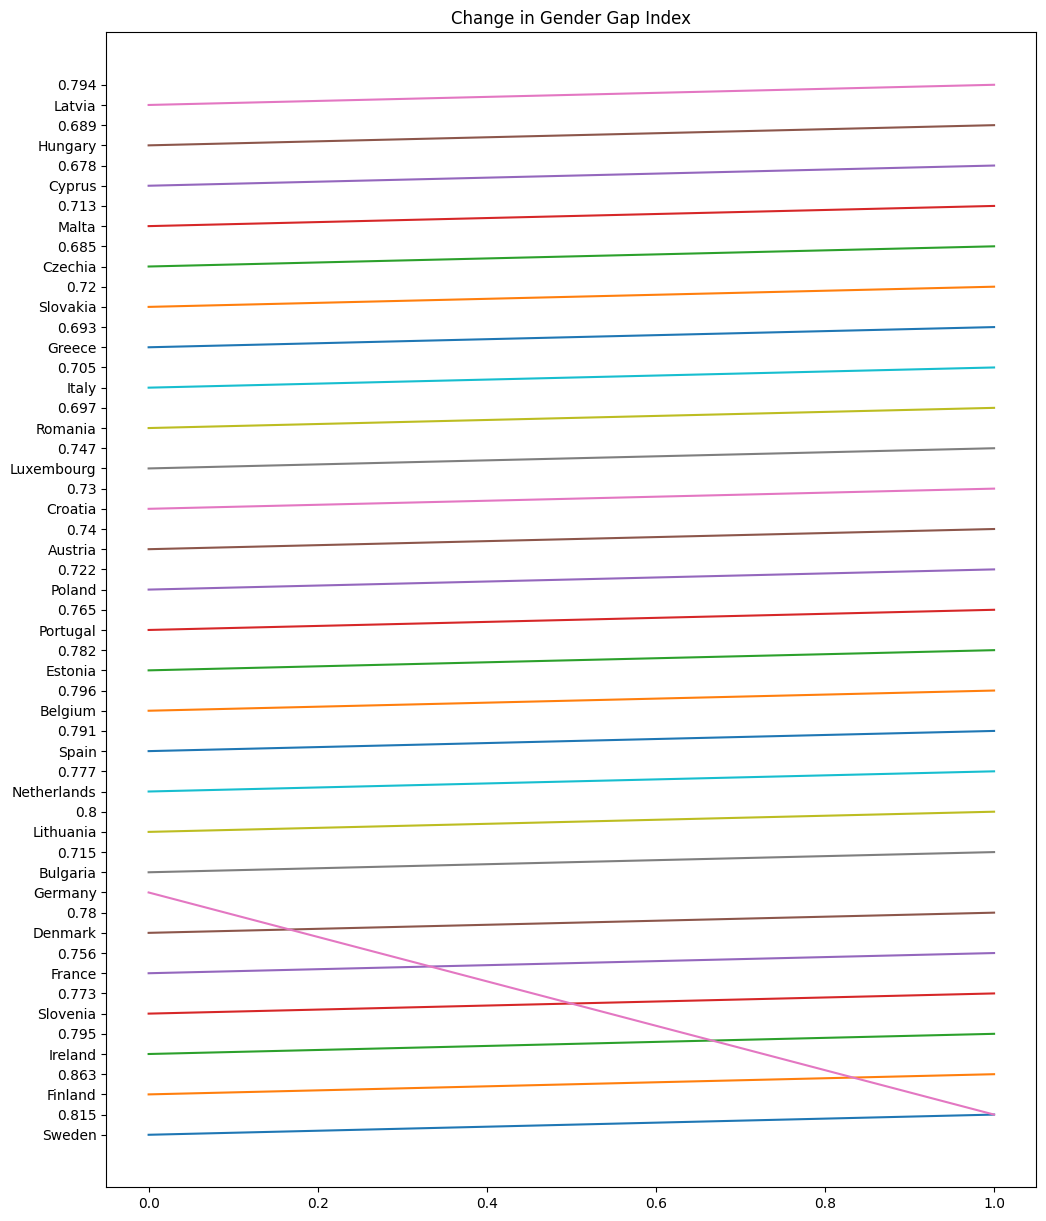

In [7]:
plt.figure(figsize=(12,15))

for country in gender_data.index:
    plt.plot([0,1], [gender_data.loc[country, start], gender_data.loc[country, end]])

plt.title("Change in Gender Gap Index")

In [8]:
#remove index column on x axis and transpose the data frame to have years as columns and countries as rows
gender_data = gender_data.set_index('Country').T

# Add a column with the European average for each year
gender_data['European Average'] = gender_data.mean(axis=1)
gender_data.head(3)

Country,Sweden,Finland,Ireland,Slovenia,France,Denmark,Germany,Bulgaria,Lithuania,Netherlands,...,Romania,Italy,Greece,Slovakia,Czechia,Malta,Cyprus,Hungary,Latvia,European Average
2014,0.8165,0.8453,0.785,0.7443,0.7588,0.8025,0.778,0.7444,0.7208,0.773,...,0.6936,0.6973,0.6784,0.6806,0.6737,0.6707,0.6741,0.6759,0.7691,0.733107
2015,0.8230,0.8500,0.807,0.7840,0.7610,0.7670,0.779,0.7220,0.7400,0.776,...,0.6930,0.7260,0.6850,0.6750,0.6870,0.6680,0.6710,0.6720,0.7520,0.737296
2016,0.8150,0.8450,0.797,0.7860,0.7550,0.7540,0.766,0.7260,0.7440,0.756,...,0.6900,0.7190,0.6800,0.6790,0.6900,0.6640,0.6840,0.6690,0.7750,0.734741


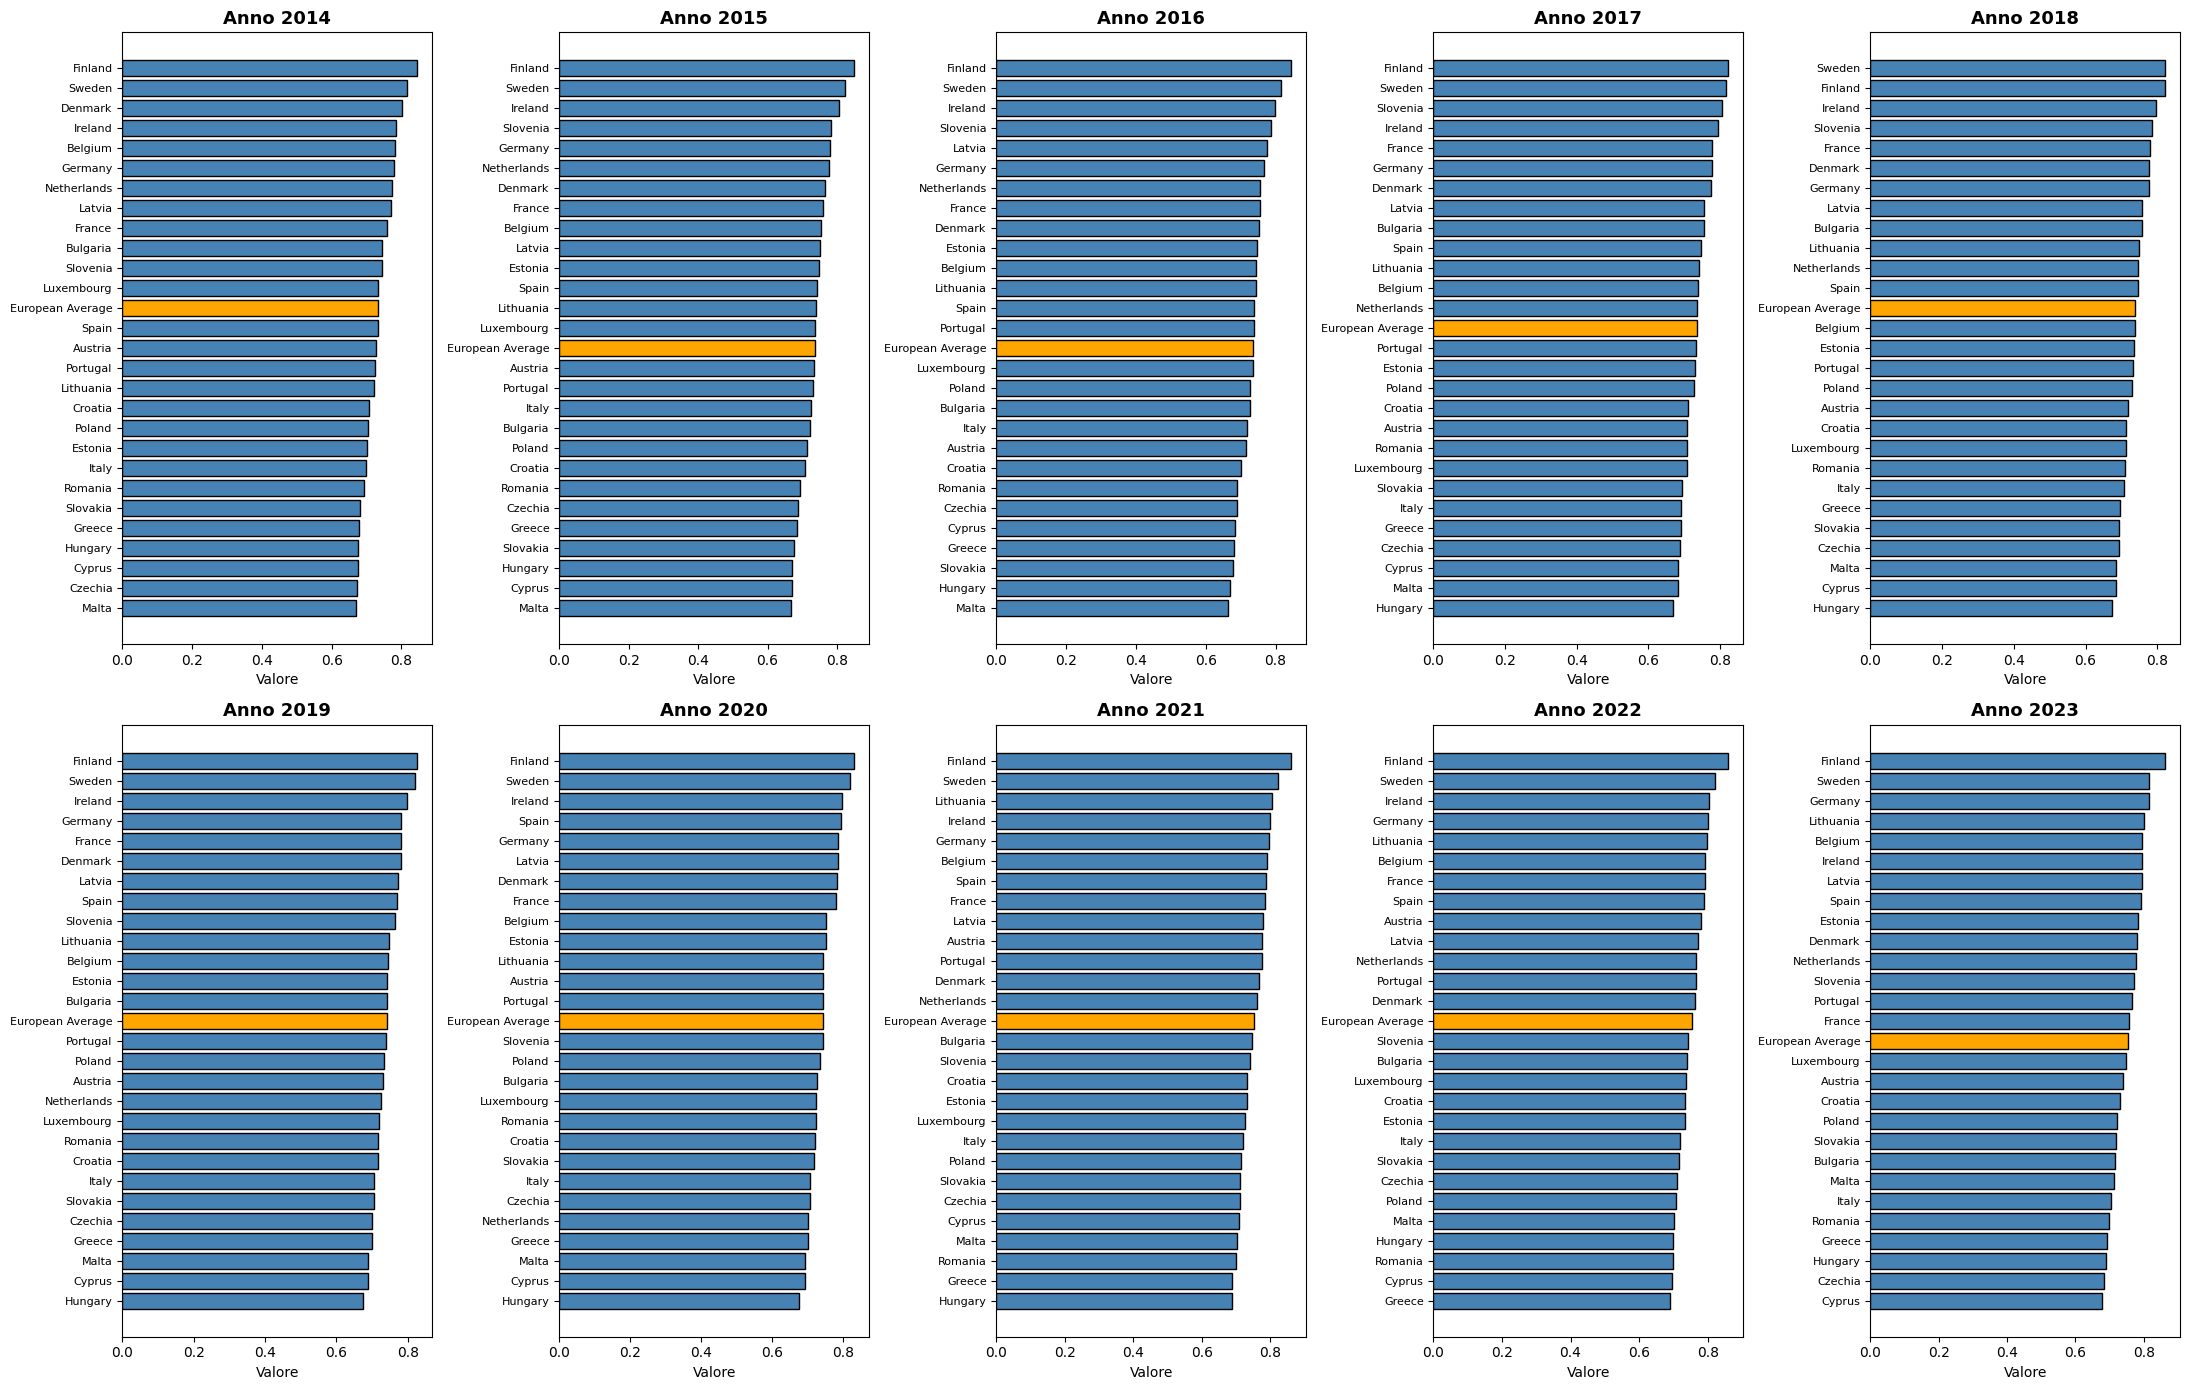

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 14))
axes = axes.flatten()

for i, year in enumerate(year_cols):
    ax = axes[i]
    serie = gender_data.loc[year].dropna().sort_values(ascending=True)

    ax.barh(serie.index, serie.values, color="steelblue", edgecolor="black")
    ax.set_title(f"Anno {year}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Valore")
    ax.tick_params(axis="y", labelsize=8)
    
    if 'European Average' in serie.index:
        avg_index = serie.index.get_loc('European Average')
        ax.patches[avg_index].set_facecolor("orange")
plt.tight_layout()
#TODO POWER BI

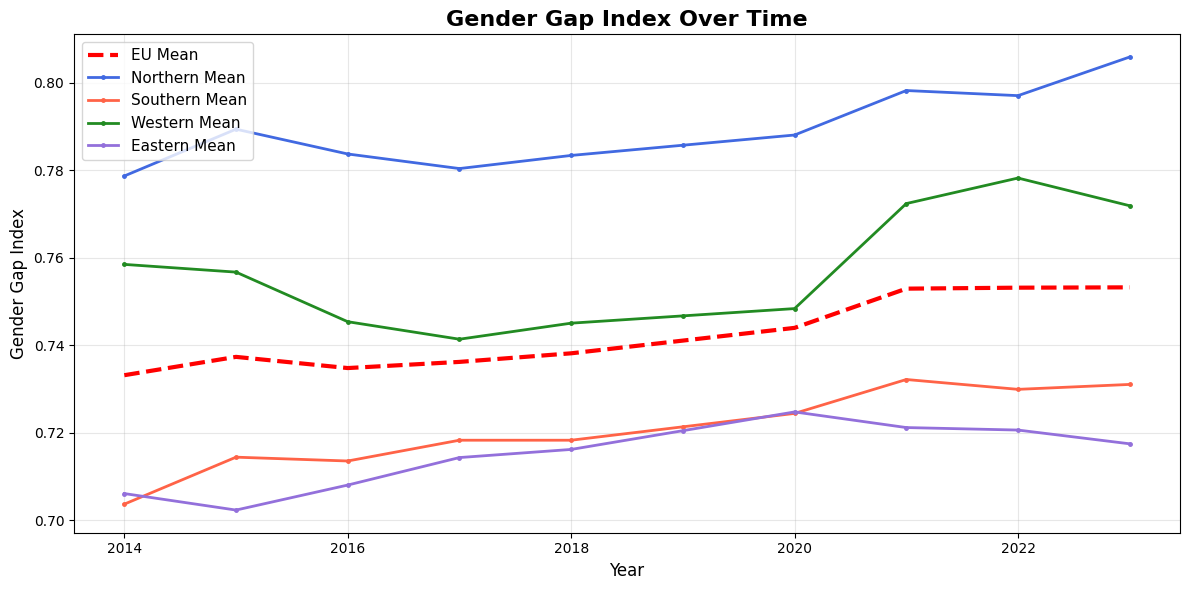

In [10]:
years = gender_data.index
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(years, gender_data['European Average'],
        label='EU Mean', color='red', linewidth=3, zorder=5, linestyle='--')

for region_name, (countries, color) in regions.items():
    if not countries:
        continue
    mean = gender_data[countries].mean(axis=1)
    ax.plot(years, mean, label=f'{region_name} Mean',
            color=color, linewidth=2, marker='.', markersize=5)

ax.set_title('Gender Gap Index Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Gender Gap Index', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()

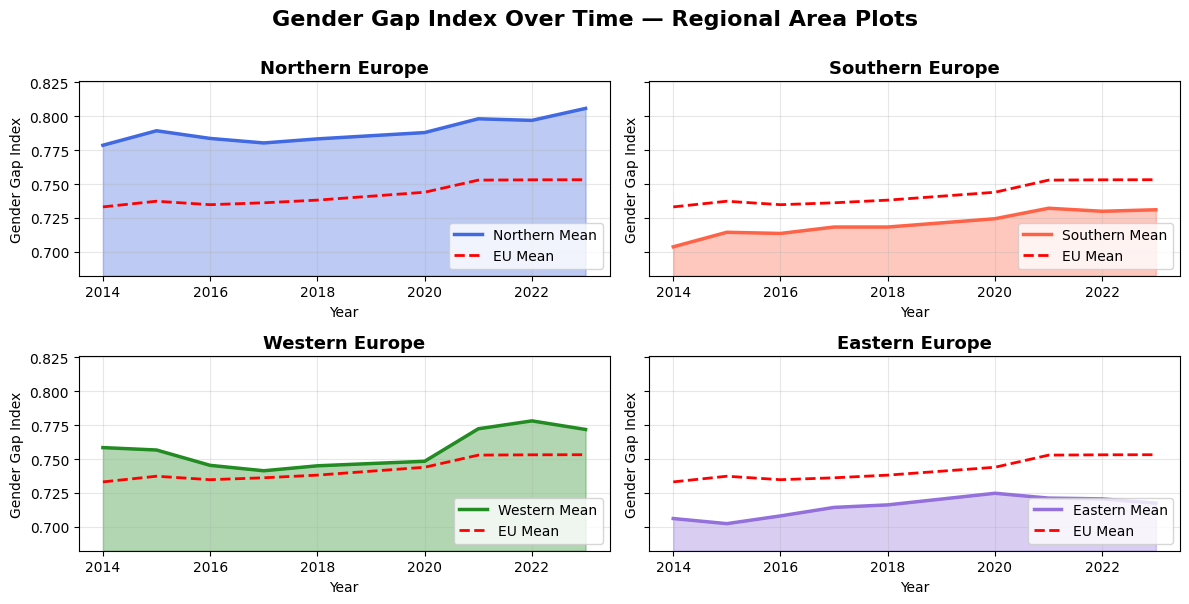

In [11]:
years = gender_data.index.astype(float)
eu_mean = gender_data['European Average']

fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharey=True)
axes = axes.flatten()

# Asse y comune: parte poco sotto il minimo per far risaltare l'area
all_means = [gender_data[c].mean(axis=1) for c, _ in regions.values() if c]
ymin = min(min(m.min() for m in all_means), eu_mean.min()) - 0.02
ymax = max(max(m.max() for m in all_means), eu_mean.max()) + 0.02

for ax, (region_name, (countries, color)) in zip(axes, regions.items()):
    if not countries:
        ax.set_visible(False)
        continue
    mean = gender_data[countries].mean(axis=1)

    # Area plot della media regionale
    ax.fill_between(years, ymin, mean, color=color, alpha=0.35)
    ax.plot(years, mean, color=color, linewidth=2.5, label=f'{region_name} Mean')

    # EU mean sovrapposto come riferimento
    ax.plot(years, eu_mean, color='red', linewidth=2,
            linestyle='--', label='EU Mean')

    ax.set_title(f'{region_name} Europe', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Gender Gap Index')
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='lower right')

fig.suptitle('Gender Gap Index Over Time — Regional Area Plots',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
# TODO REPORT

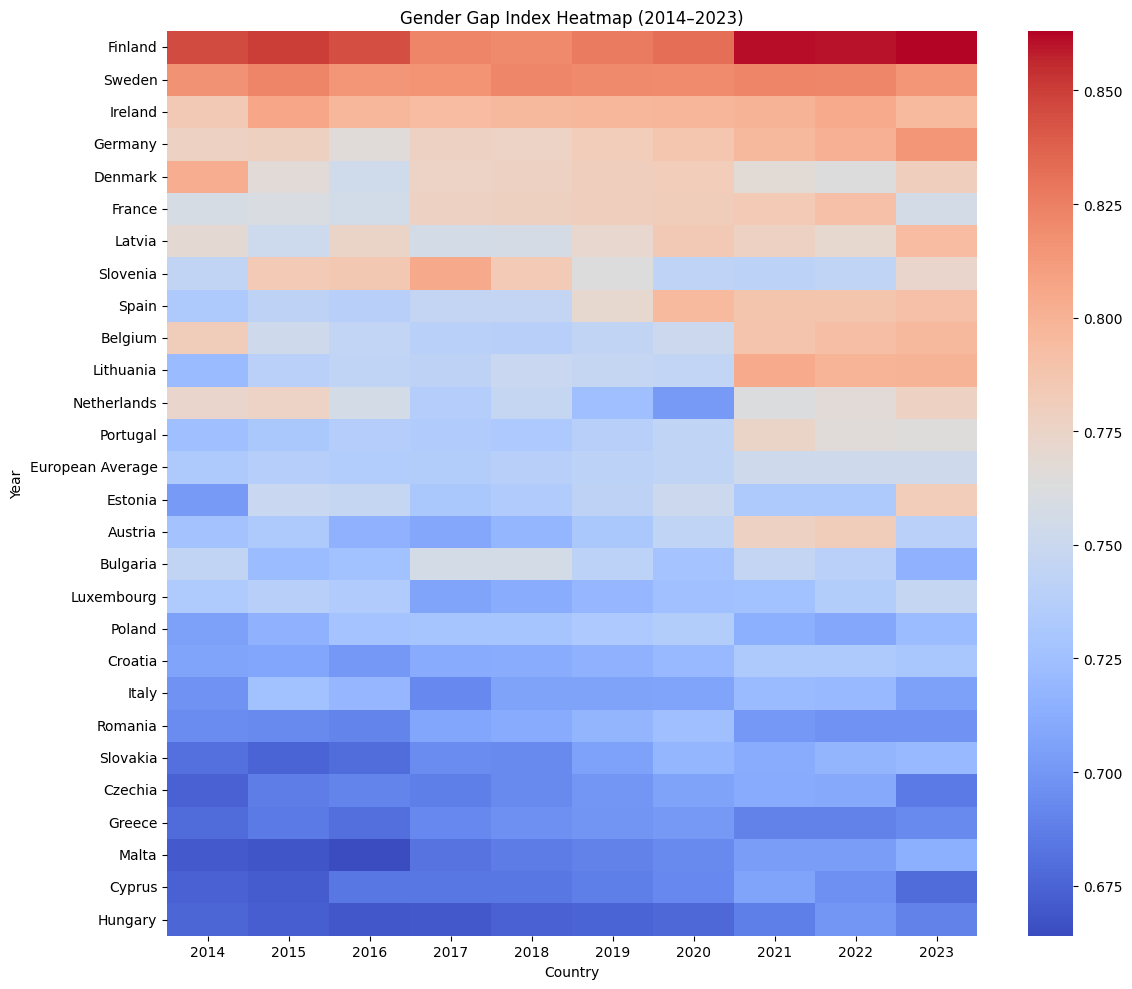

In [13]:
# we could order the countries by their average gender gap index
average_gender_gap = gender_data.mean()
ordered_countries = average_gender_gap.sort_values(ascending=False).index

# replot the heatmap with ordered countries
plt.figure(figsize=(12,10))
sns.heatmap(gender_data[ordered_countries].T, cmap="coolwarm", annot=False)
plt.title("Gender Gap Index Heatmap (2014–2023)")
plt.xlabel("Country")
plt.ylabel("Year")
plt.tight_layout()
# TODO REPORT

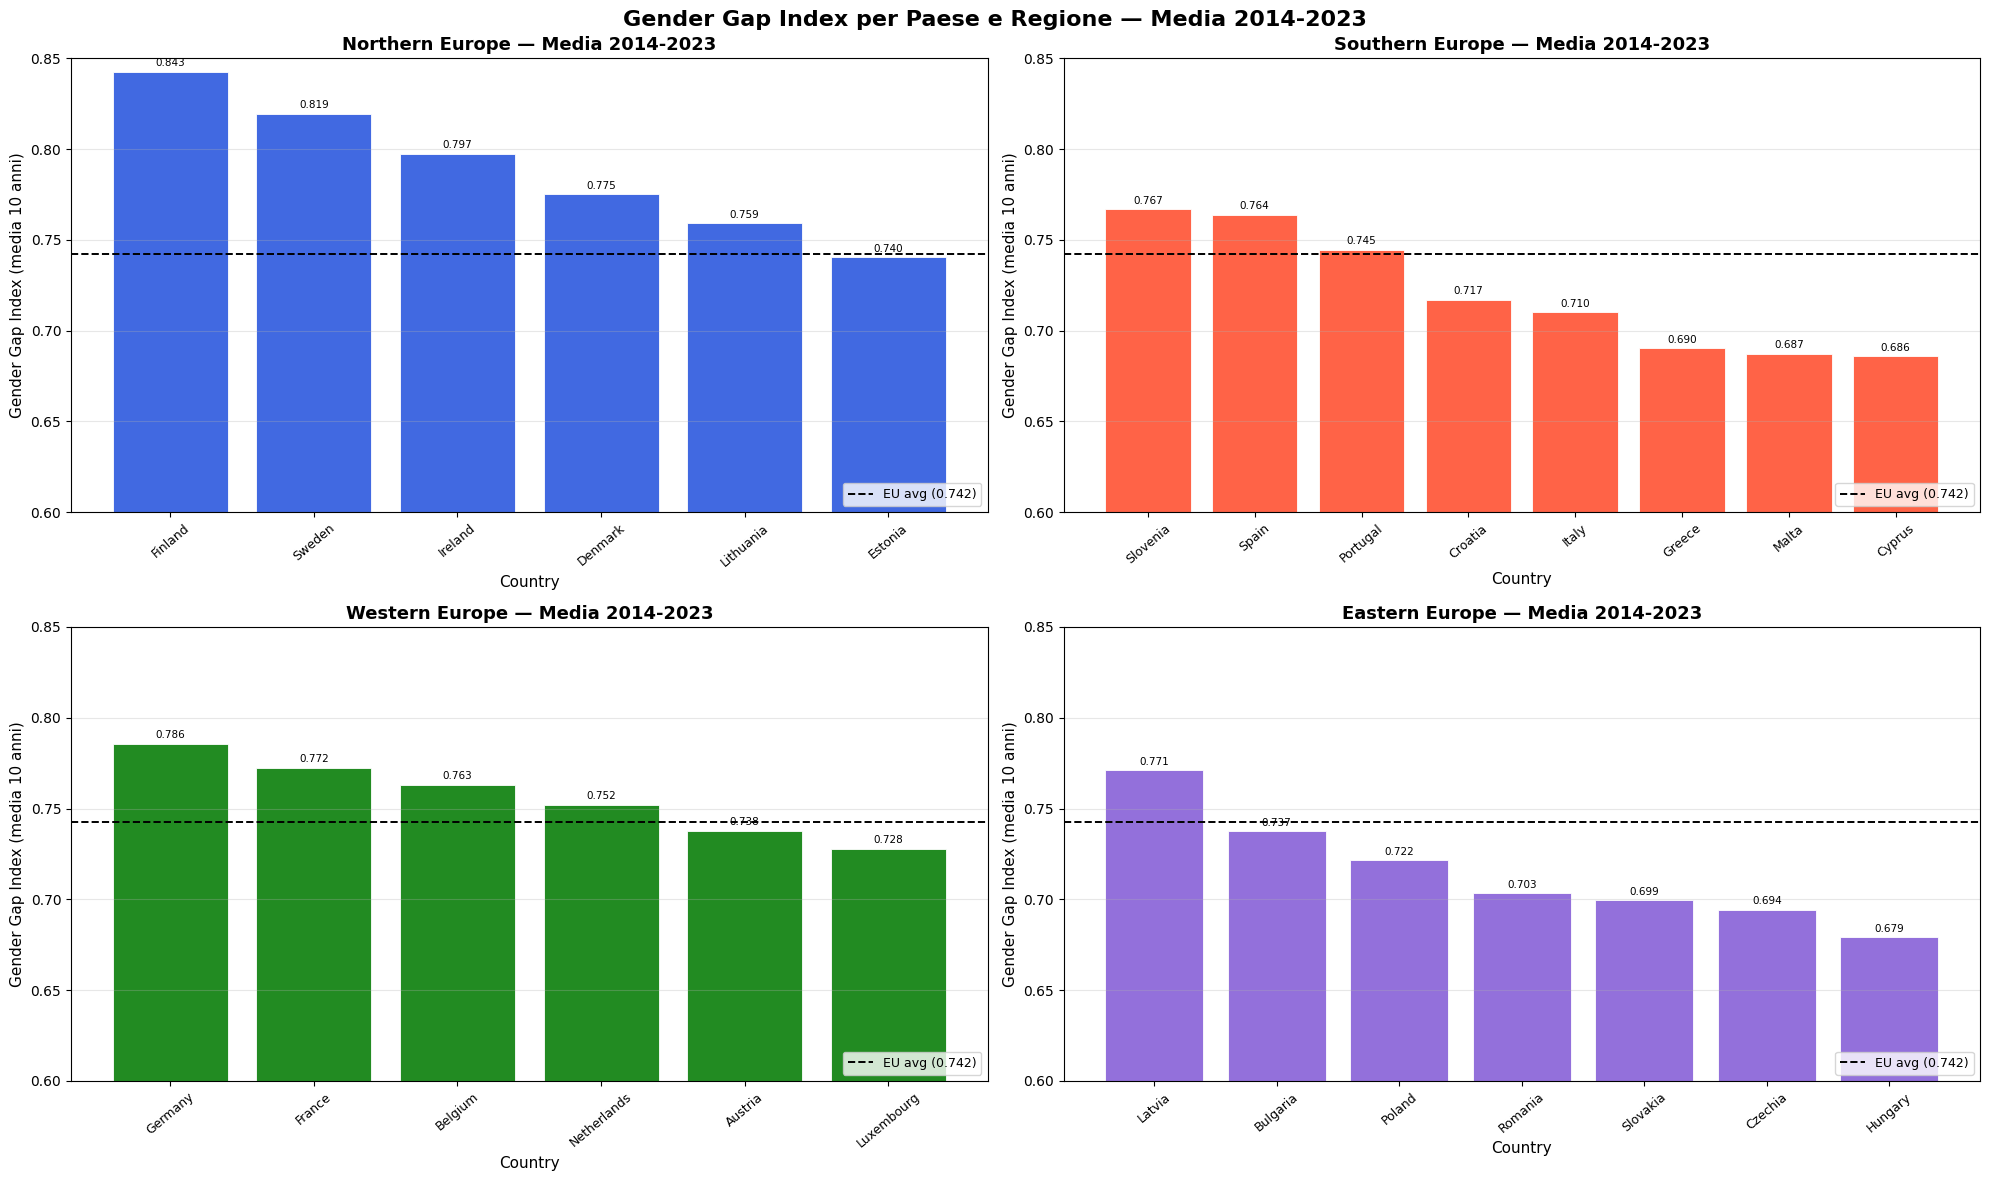

In [26]:
# 4 subplots — un paese per tacca sull'asse x, media 2014-2023 in y
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

eu_avg = gender_data['European Average'].mean()

for ax, (region, (countries, color)) in zip(axes, regions.items()):
    available = [c for c in countries if c in gender_data.columns]
    if not available:
        ax.set_visible(False)
        continue

    values = gender_data[available].mean(axis=0).sort_values(ascending=False)

    bars = ax.bar(values.index, values.values, color=color, edgecolor='white', linewidth=0.6)

    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

    ax.axhline(eu_avg, color='black', linewidth=1.4, linestyle='--', label=f'EU avg ({eu_avg:.3f})')

    ax.set_title(f'{region} Europe — Media 2014-2023', fontsize=13, fontweight='bold')
    ax.set_xlabel('Country', fontsize=11)
    ax.set_ylabel('Gender Gap Index (media 10 anni)', fontsize=11)
    ax.set_ylim(0.60, 0.85)
    ax.tick_params(axis='x', rotation=40, labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('Gender Gap Index per Paese e Regione — Media 2014-2023',
             fontsize=16, fontweight='bold')
plt.tight_layout()

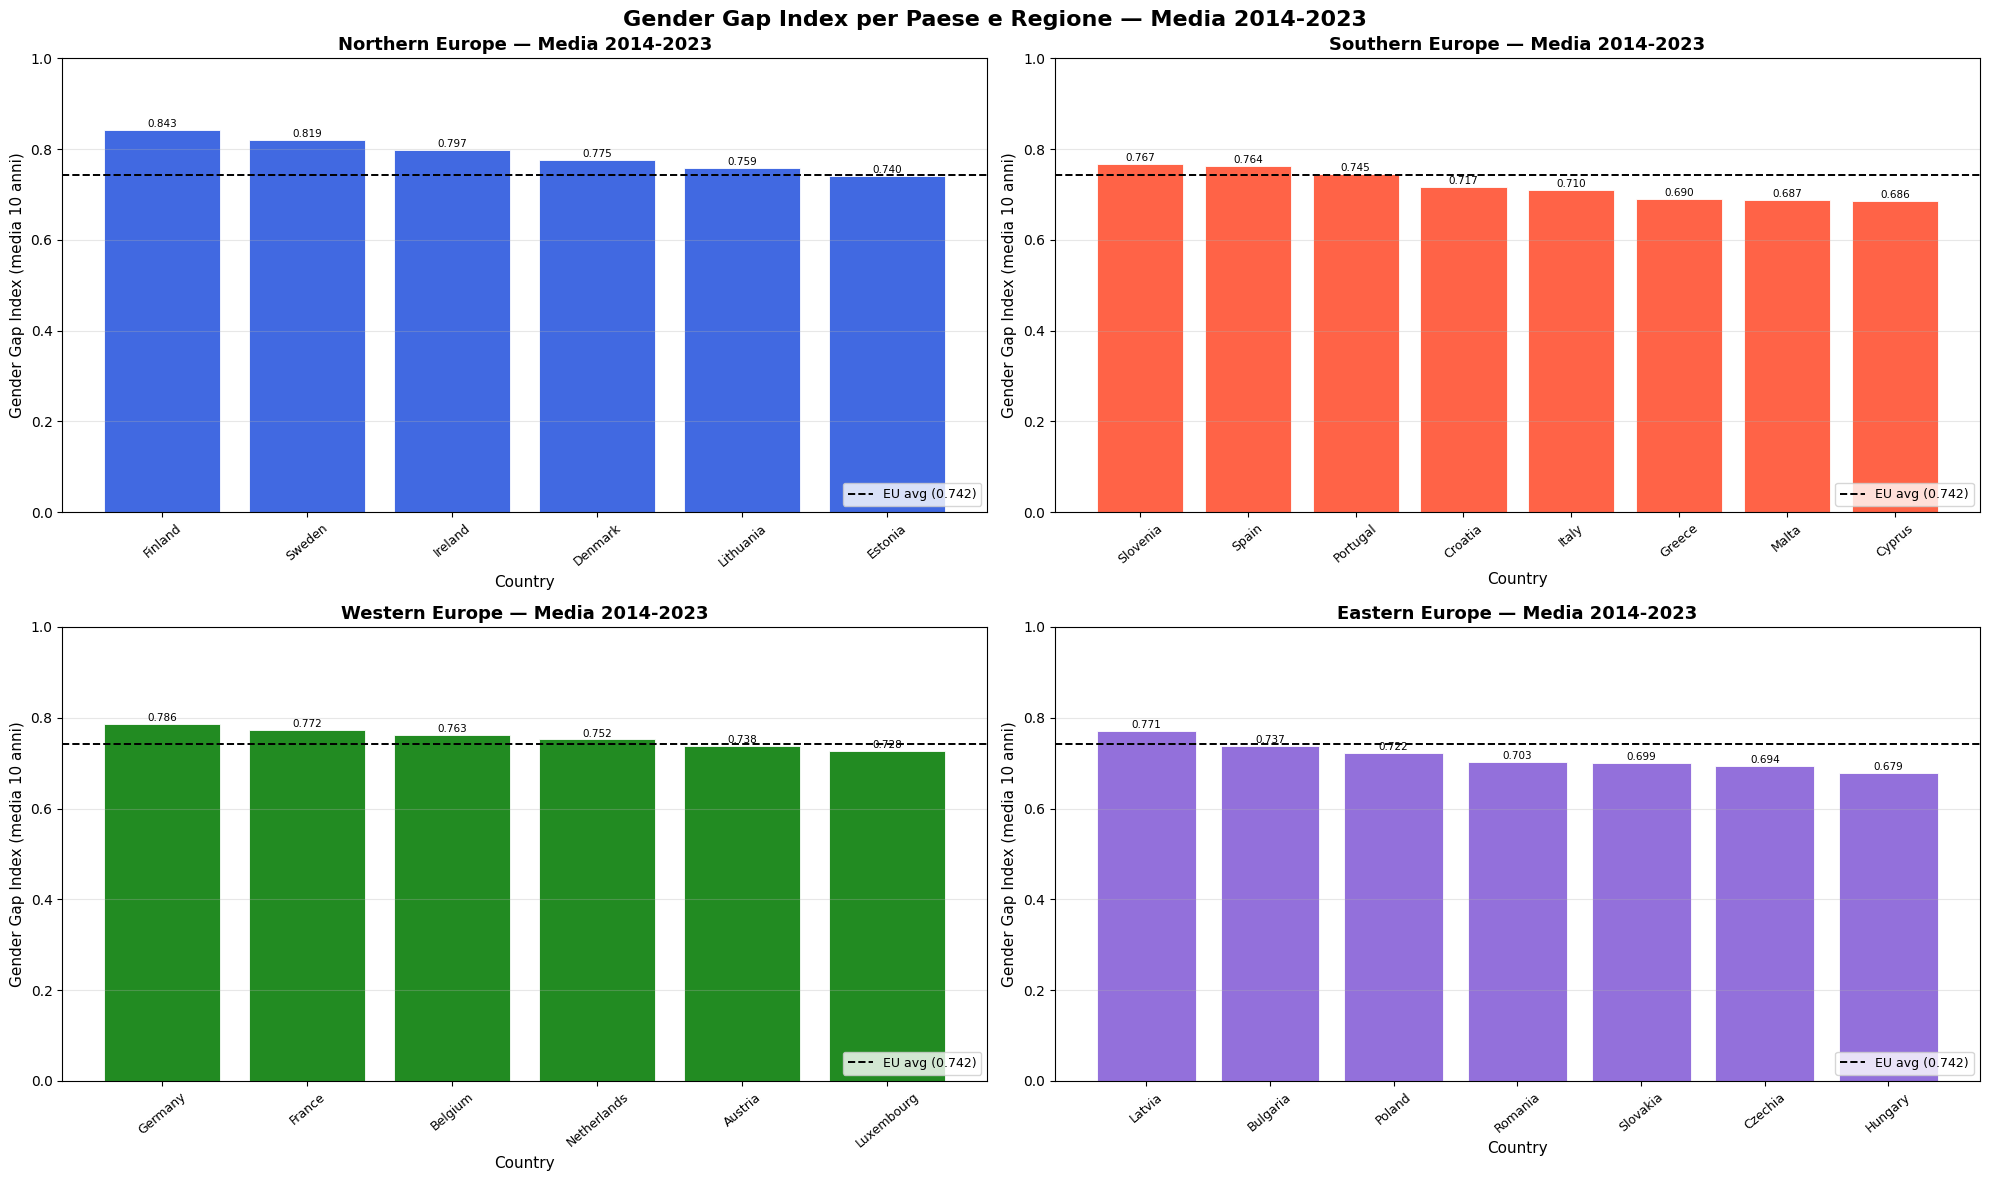

In [24]:
# 4 subplots — un paese per tacca sull'asse x, media 2014-2023 in y
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

eu_avg = gender_data['European Average'].mean()

for ax, (region, (countries, color)) in zip(axes, regions.items()):
    available = [c for c in countries if c in gender_data.columns]
    if not available:
        ax.set_visible(False)
        continue

    values = gender_data[available].mean(axis=0).sort_values(ascending=False)

    bars = ax.bar(values.index, values.values, color=color, edgecolor='white', linewidth=0.6)

    for bar, val in zip(bars, values.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

    ax.axhline(eu_avg, color='black', linewidth=1.4, linestyle='--', label=f'EU avg ({eu_avg:.3f})')

    ax.set_title(f'{region} Europe — Media 2014-2023', fontsize=13, fontweight='bold')
    ax.set_xlabel('Country', fontsize=11)
    ax.set_ylabel('Gender Gap Index (media 10 anni)', fontsize=11)
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='x', rotation=40, labelsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('Gender Gap Index per Paese e Regione — Media 2014-2023',
             fontsize=16, fontweight='bold')
plt.tight_layout()